<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Machine Learning
### Sommersemester 2026
Prof. Dr. Stefan Goetze

## Fashion MNIST mit Keras
**Nach dem Tutorial von Google:** https://www.tensorflow.org/tutorials/keras/classification

In diesem Notebook geht es um das selbe Thema wie schon beim Aufgabenblatt zur Logistischen Regression, nämlich den *Fashion MNIST* Datensatz.
An dieser Stelle wollen wir allerdings statt eine Multi-Klassen Logistischen Regression ein Neuronales Netz einsetzen.

Um den Code so kompakt wie möglich zu halten, verwenden wir die Keras API.
Zusätzlich benötigen Wir Funktionen aus NumPy und Matplotlib.

In [2]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)
%load_ext tensorboard

2.21.0


Im Arbeitsblatt zur Logistischen Regression habe wir den Datensatz noch über eine URL aus einem Cloud Speicher heruntergeladen.
Der Fashion MNIST Datensatz ist aber ebenfalls als Standard-Beispiel über die Keras Bibliothek erhältlich.
Daher können wir ihn komfortabel über einen Keras-Aufruf [`keras.datasets.fashion_mnist.load_data()`](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) herunterladen und direkt auf Trainings- und Testdatensätze aufteilen:

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
test_images = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Auf die Labels wenden wir ein [`one_hot`](https://www.tensorflow.org/api_docs/python/tf/one_hot)-Encoding an.

In [4]:
train_labels_ohe = tf.one_hot(train_labels, depth=10)
test_labels_ohe = tf.one_hot(test_labels, depth=10)

iLabel = np.random.randint(0,test_labels.shape[0])
print('Example for label no ' + str(iLabel) +' from train set: ' + str(train_labels[iLabel]) + ' (which is after one-hot-encoding:)' )
print(train_labels_ohe[iLabel])

print('Example label no ' + str(iLabel) +' from test set: ' + str(test_labels[iLabel]) + ' (which is after one-hot-encoding:)' )
print(test_labels_ohe[iLabel])

Example for label no 5481 from train set: 5 (which is after one-hot-encoding:)
tf.Tensor([0. 0. 0. 0. 0. 1. 0. 0. 0. 0.], shape=(10,), dtype=float32)
Example label no 5481 from test set: 2 (which is after one-hot-encoding:)
tf.Tensor([0. 0. 1. 0. 0. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


Der Trainingsdatensatz besteht aus $60000$ Bildern und der Testdatensatz aus $10000$ Bildern, mit jeweils einer Dimension von $28 \times 28$ Pixeln.

In [5]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


Natürlich können wir uns ein zufälliges ausgewähltes Bild ansehen:

In [9]:
print(train_images[iLabel].shape)
print(train_images[iLabel].reshape(28,28).shape)

(28, 28, 1)
(28, 28)


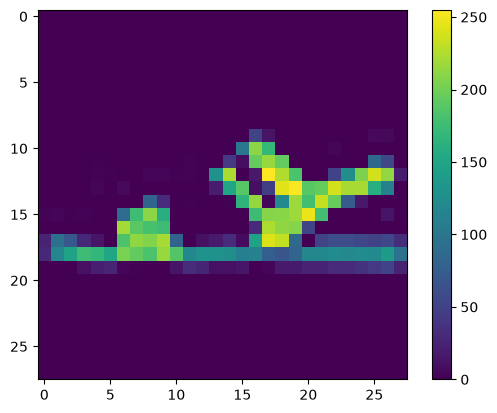

In [6]:
plt.imshow(train_images[iLabel].reshape(28,28))
plt.colorbar();

Die 28x28 Pixel großen Bilder bestehen aus 8-bit Grauwerten.
Um die Piwelwerte in den Bereich $[0,1]$ zu skalieren, teilen wir alle Pixel durch 255.

In [10]:
print("Minimum value of train set (before normalisation): " + str(np.min(train_images)))
print("Maximum value of test set (before normalisation): " + str(np.max(test_images)))

#Pixelwerte nach [0,1] skalieren
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Minimum value of train set (after normalisation): " + str(np.min(train_images)))
print("Maximum value of test set (after normalisation): " + str(np.max(test_images)))

Minimum value of train set (before normalisation): 0
Maximum value of test set (before normalisation): 255
Minimum value of train set (after normalisation): 0.0
Maximum value of test set (after normalisation): 1.0


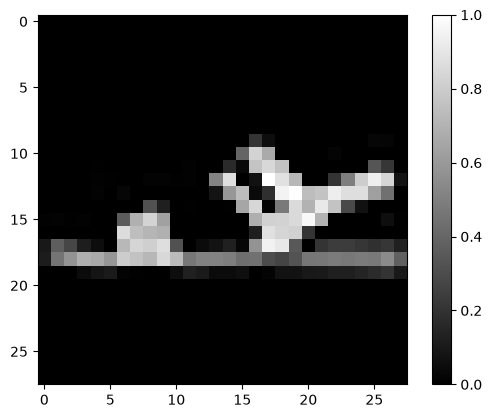

In [11]:
plt.imshow(train_images[iLabel].reshape(28,28), cmap='gray')
plt.colorbar();

Nun erzeugen wir ein [sequentielles Keras Modell](https://keras.io/guides/sequential_model/), dazu verwenden wir die Funktion [`keras.Sequential()`](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential).

Zu diesem Modell können wir nun mit [`model.add()`](https://keras.io/guides/sequential_model/) Schichten hinzufügen.
Entwerfen Sie selbst eine Mehrschichtiges neuronales Netz.
Wählen Sie die Anzahl der Neuronen und die Aktivierungsfunktionen der einzelnen Schichten aus.

In [12]:
#Modell definieren
model = tf.keras.Sequential()
# Must define the input shape in the first layer of the neural network
model.add(tf.keras.layers.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=2, padding='same', activation='relu')) 
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=2, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=2))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
# Take a look at the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       401,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,778 (1.57 MB)

 Trainable params: 412,778 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

Keras bietet die Möglichkeit, Modelle zu [speichern und später wieder zu laden](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/). Der folgende Code-Block kann verwendet werden um ggf. zu einem früheren Zeitpunkt gespeicherte Modell-Dateien zu löschen. Das Modell kann im [`.h5`-Format](https://de.wikipedia.org/wiki/Hierarchical_Data_Format) oder im nativen [`.keras`-Datenformat](https://www.tensorflow.org/guide/keras/serialization_and_saving) vorliegen.

In [33]:
# delete saved model files and logs in case you want to start fresh
import glob
from math import log
from pathlib import Path


bDeleteModelFilesAndLogs = True
if bDeleteModelFilesAndLogs==True:
    Path('./FashionMNIST_CNN.h5').unlink(missing_ok=True)
    Path('./FashionMNIST_CNN.keras').unlink(missing_ok=True)

    logs = Path('./logs/')
    if logs.exists():
        files = glob.glob(str(logs) + '*')
        for f in files:
            Path(f).unlink()
        logs.rmdir()
    #!rm -rf ./logs/*
    print("Model files and logs deleted")

PermissionError: [WinError 5] Zugriff verweigert: 'logs'

In [28]:
import os
reuse = True
model_file_extension = ".keras" # ".h5"
if(reuse == True and os.path.exists("FashionMNIST_CNN"+model_file_extension)):
    print('Loading exising FashionMNIST_CNN'+model_file_extension+' model')
    model = keras.models.load_model("FashionMNIST_CNN"+model_file_extension)
else:
    #Modell erzeugen
    model.compile(optimizer='Adam',
                  loss='sparse_categorical_crossentropy',
                  #loss='categorical_crossentropy',
                  metrics=['accuracy'])

# create logging directory for TensorBoard
import datetime
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S")) # create folder name
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

Loading exising FashionMNIST_CNN.keras model


In [ ]:
#Modell trainieren
model.fit(train_images, train_labels,
          epochs=5,
          #validation_data=(test_images, test_labels),
          callbacks=[tensorboard_callback]
          )

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8917 - loss: 0.2930
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8944 - loss: 0.2810
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8979 - loss: 0.2758
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9014 - loss: 0.2638
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9044 - loss: 0.2605
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9054 - loss: 0.2542
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9079 - loss: 0.2486
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9085 - loss: 0.2479
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9105 - loss: 0.2405
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9111 - loss: 0.2381
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9123 - loss: 0.2342
Epoch 12/20
1875/18

Wir können unser Modell im [`.h5`-Format](https://de.wikipedia.org/wiki/Hierarchical_Data_Format) oder im nativen [`.keras`-Datenformat](https://www.tensorflow.org/guide/keras/serialization_and_saving) speichern.

In [30]:
model.save("FashionMNIST_CNN"+model_file_extension)

In [31]:
#Trainiertes Modell auswerten
test_loss, test_acc = model.evaluate (test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9200 - loss: 0.2274
Test accuracy: 0.9200000166893005


Die `log`-Dateien können mit [TensorBoard](https://keras.io/api/callbacks/tensorboard/) visualisiert werden.

In [32]:
%tensorboard --logdir logs

Reusing TensorBoard on port 6006 (pid 13720), started 0:12:32 ago. (Use '!kill 13720' to kill it.)

Definieren Sie Ihr Modell erneut mit der [Funktionalen API von Keras](https://keras.io/guides/functional_api/).

In [35]:
#Funktionale abhängigkeiten
inputs = keras.Input(shape=(28, 28))

finputs = keras.layers.Flatten()(inputs)
l1 = keras.layers.Dense(128, activation=tf.nn.relu)(finputs)
outputs = keras.layers.Dense(10, activation=tf.nn.softmax)(l1)

#Modell definieren
model = keras.Model(inputs, outputs)

#Modell erzeugen
model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [36]:
# Take a look at the model summary
model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# printing some information about the data
print("Type of train_images: " + str(train_images.dtype))
print("Shape of train_images: " + str(train_images.shape))

print("Type of test_images: " + str(test_images.dtype))
print("Shape of test_images: " + str(test_images.shape))

train_labels

Type of train_images: float64
Shape of train_images: (60000, 28, 28, 1)
Type of test_images: float64
Shape of test_images: (10000, 28, 28, 1)


array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [38]:
#Modell trainieren
model.fit(train_images, train_labels, epochs=5)

#Trainiertes Modell auswerten
test_loss, test_acc = model.evaluate (test_images, test_labels)
print('Test accuracy:', test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 952us/step - accuracy: 0.7676 - loss: 0.7264
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.8270 - loss: 0.5105
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 863us/step - accuracy: 0.8388 - loss: 0.4689
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 856us/step - accuracy: 0.8459 - loss: 0.4454
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - accuracy: 0.8519 - loss: 0.4286
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.8426 - loss: 0.4534
Test accuracy: 0.8425999879837036


Beiträge zu diesem Notebook: [Heiner Giefers](https://github.com/hgiefers), [Stefan Goetze](https://github.com/Stefan-Goe)